In [23]:
!pip install python-docx

In [24]:
from google.colab import files

uploaded = files.upload()

Saving kumarajiva.docx to kumarajiva (1).docx
Saving xuanzang.docx to xuanzang (1).docx


In [26]:
KUMARA_FILE = "kumarajiva.docx"
XUANZANG_FILE = "xuanzang.docx"

In [28]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 找 Noto CJK 字型
font_candidates = [
    f for f in fm.findSystemFonts()
    if "NotoSansCJK" in f
]

# 設定字型
if font_candidates:
    font_prop = fm.FontProperties(fname=font_candidates[0])
    plt.rcParams["font.family"] = font_prop.get_name()

plt.rcParams["axes.unicode_minus"] = False

print("Font configured successfully.")

Font configured successfully.


In [29]:
!apt-get update -qq
!apt-get install -y fonts-noto-cjk
!pip install python-docx

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.


Using font: Noto Sans CJK JP
Font path: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
Text length:
Kumarajiva: 5174
Xuanzang:   8225

Number of chunks:
Kumarajiva: 11
Xuanzang:   19

Explained variance ratio:
PC1: 0.1375
PC2: 0.1217


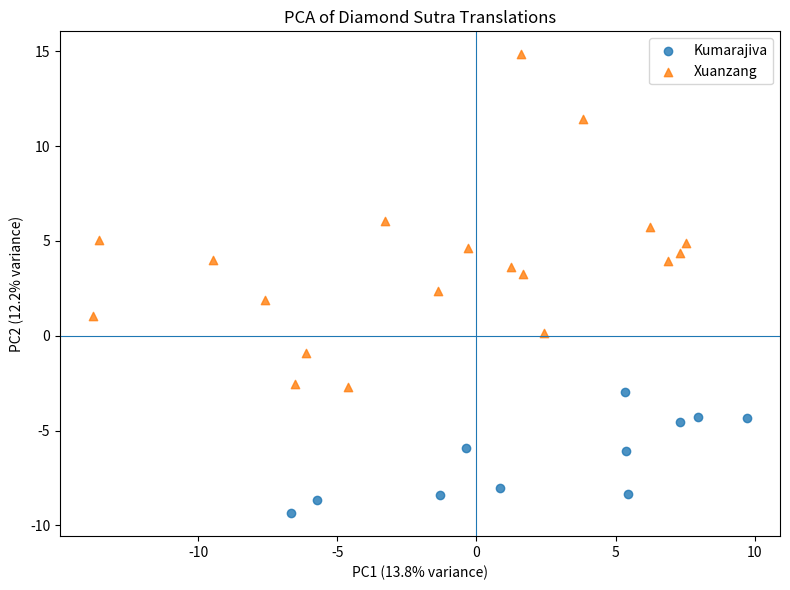


PC1 loadings:
   feature   loading
0        云  0.126305
1        何  0.125294
2        佛  0.114802
3        名  0.114556
4        世  0.110039
5        尊  0.108984
6        言  0.098894
7        七  0.096989
8        寶  0.096989
9        滿  0.094207
10       議 -0.097925
11       悉 -0.098089
12       時 -0.099830
13       稱 -0.101837
14       利 -0.101933
15       聽 -0.102929
16       乘 -0.103660
17       當 -0.105454
18       復 -0.107823
19       事 -0.116081


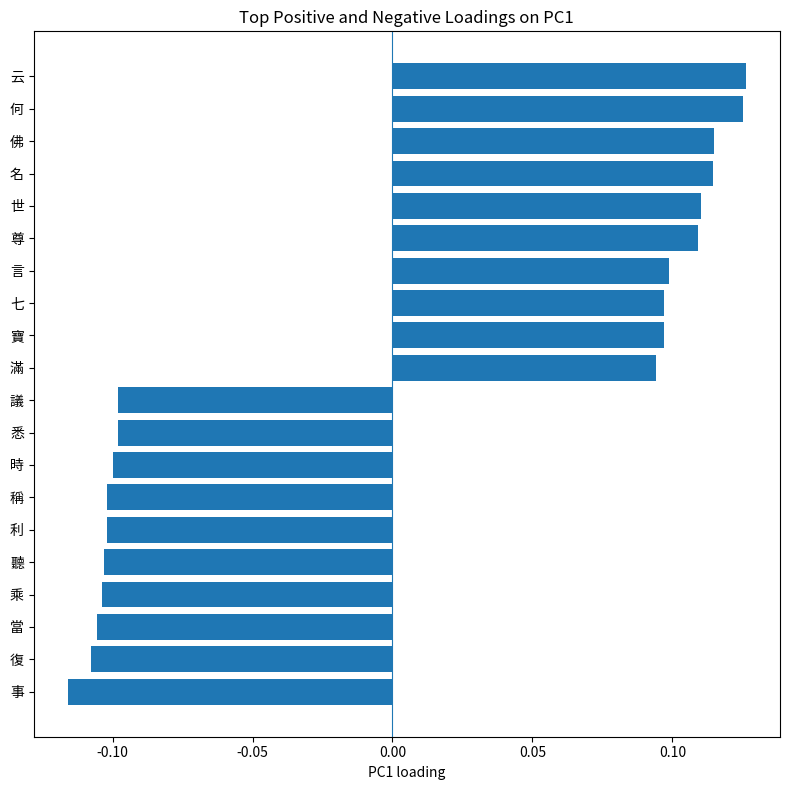


PC2 loadings:
   feature   loading
0        伽  0.153194
1        由  0.132415
2        善  0.124664
3        殑  0.122578
4        緣  0.121937
5        因  0.121937
6        假  0.120069
7        使  0.120069
8        逝  0.117568
9        開  0.112599
10       耨 -0.092541
11       藐 -0.092541
12       即 -0.095643
13       人 -0.097581
14       修 -0.098213
15       萬 -0.104699
16       眾 -0.117464
17       須 -0.123078
18       提 -0.127876
19       菩 -0.141054


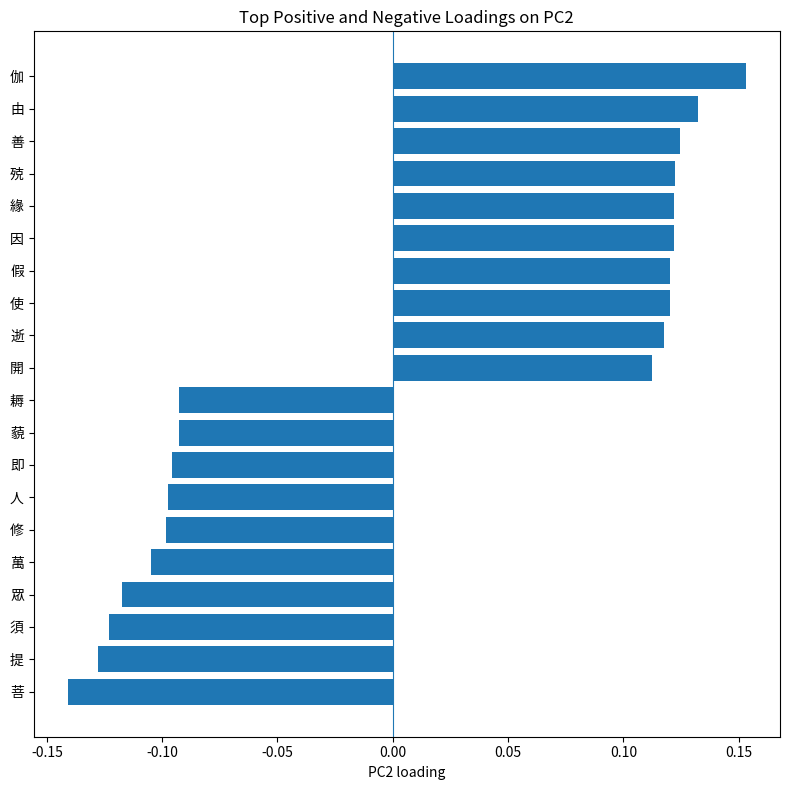


Entropy summary:
            count      mean       std       min       25%       50%       75%  \
translator                                                                      
Kumarajiva   11.0  6.665231  0.264239  6.156603  6.525055  6.648385  6.846410   
Xuanzang     19.0  6.764631  0.276437  6.264335  6.643681  6.774885  6.966044   

                 max  
translator            
Kumarajiva  7.032779  
Xuanzang    7.208694  

Entropy tests:
Mann-Whitney U: 83.0000, p=0.3661
Welch t-test: -0.9761, p=0.3397


<Figure size 600x500 with 0 Axes>

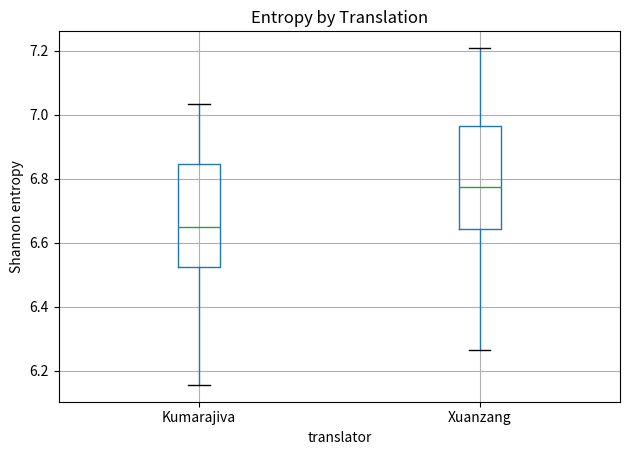


Output files:
- pca_scatter.png
- pc1_loadings.csv
- pc2_loadings.csv
- pc1_loadings_bar.png
- pc2_loadings_bar.png
- pca_coordinates.csv
- entropy_summary.csv
- entropy_tests.csv
- entropy_boxplot.png


In [30]:
# -*- coding: utf-8 -*-

import os
import re
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from docx import Document
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu, ttest_ind


# =========================
# Chinese font setting
# =========================

font_candidates = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
]

font_path = None

for path in font_candidates:
    if os.path.exists(path):
        font_path = path
        break

if font_path is None:
    raise RuntimeError(
        "No Noto CJK font found. Please run: "
        "!apt-get install -y fonts-noto-cjk"
    )

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print("Using font:", font_prop.get_name())
print("Font path:", font_path)


# =========================
# Parameters
# =========================

KUMARA_FILE = "羅什版.docx"
XUANZANG_FILE = "玄奘版.docx"

WINDOW_SIZE = 800
STRIDE = 400
TOP_N_FEATURES = 300
KEEP_PUNCTUATION = False
TOP_N_LOADINGS = 10


# =========================
# Read DOCX
# =========================

def read_docx(path):
    doc = Document(path)
    return "\n".join(p.text for p in doc.paragraphs)


# =========================
# Clean text
# =========================

def clean_text(text, keep_punctuation=False):
    text = text.replace("\u3000", "")
    text = text.replace("\xa0", "")
    text = re.sub(r"\s+", "", text)

    if keep_punctuation:
        text = re.sub(r"[A-Za-z0-9]", "", text)
    else:
        text = re.sub(r"[^\u4e00-\u9fff]", "", text)

    return text


# =========================
# Sliding window
# =========================

def sliding_window(text, window_size=800, stride=400):
    chunks = []

    for start in range(0, len(text) - window_size + 1, stride):
        chunks.append(text[start:start + window_size])

    return chunks


# =========================
# Character-frequency vectors
# =========================

def build_vocab(chunks, top_n=300):
    counter = Counter()

    for chunk in chunks:
        counter.update(chunk)

    return [char for char, _ in counter.most_common(top_n)]


def chunk_to_freq_vector(chunk, vocab):
    counter = Counter(chunk)
    total = len(chunk)

    return np.array([
        counter.get(char, 0) / total
        for char in vocab
    ])


# =========================
# Shannon entropy
# =========================

def shannon_entropy(text):
    counter = Counter(text)
    total = len(text)

    probs = [count / total for count in counter.values()]

    return -sum(
        p * math.log2(p)
        for p in probs
        if p > 0
    )


# =========================
# Loading table
# =========================

def make_loading_table(loading_df, top_n=10):
    positive_df = (
        loading_df[loading_df["loading"] > 0]
        .sort_values("loading", ascending=False)
        .head(top_n)
    )

    negative_strongest = (
        loading_df[loading_df["loading"] < 0]
        .sort_values("loading", ascending=True)
        .head(top_n)
    )

    negative_df = negative_strongest.sort_values(
        "loading",
        ascending=False
    )

    table_df = pd.concat(
        [positive_df, negative_df],
        ignore_index=True
    )

    return table_df


# =========================
# Loading plot
# =========================

def plot_loading_bar(table_df, component_name, output_file):
    plot_df = table_df.iloc[::-1]

    plt.figure(figsize=(8, 8))

    plt.barh(
        plot_df["feature"],
        plot_df["loading"]
    )

    plt.axvline(0, linewidth=0.8)

    plt.xlabel(f"{component_name} loading")
    plt.title(f"Top Positive and Negative Loadings on {component_name}")

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()


# =========================
# Main analysis
# =========================

def main():
    kumara_raw = read_docx(KUMARA_FILE)
    xuanzang_raw = read_docx(XUANZANG_FILE)

    kumara_text = clean_text(kumara_raw, KEEP_PUNCTUATION)
    xuanzang_text = clean_text(xuanzang_raw, KEEP_PUNCTUATION)

    print("Text length:")
    print(f"Kumarajiva: {len(kumara_text)}")
    print(f"Xuanzang:   {len(xuanzang_text)}")

    kumara_chunks = sliding_window(
        kumara_text,
        WINDOW_SIZE,
        STRIDE
    )

    xuanzang_chunks = sliding_window(
        xuanzang_text,
        WINDOW_SIZE,
        STRIDE
    )

    print("\nNumber of chunks:")
    print(f"Kumarajiva: {len(kumara_chunks)}")
    print(f"Xuanzang:   {len(xuanzang_chunks)}")

    all_chunks = kumara_chunks + xuanzang_chunks

    labels = (
        ["Kumarajiva"] * len(kumara_chunks)
        +
        ["Xuanzang"] * len(xuanzang_chunks)
    )

    vocab = build_vocab(all_chunks, TOP_N_FEATURES)

    X = np.array([
        chunk_to_freq_vector(chunk, vocab)
        for chunk in all_chunks
    ])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    print("\nExplained variance ratio:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")

    pca_df = pd.DataFrame({
        "translator": labels,
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "entropy": [
            shannon_entropy(chunk)
            for chunk in all_chunks
        ]
    })

    pca_df.to_csv(
        "pca_coordinates.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # =====================
    # PCA scatter plot
    # =====================

    plt.figure(figsize=(8, 6))

    for translator, marker in [
        ("Kumarajiva", "o"),
        ("Xuanzang", "^")
    ]:
        subset = pca_df[pca_df["translator"] == translator]

        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=translator,
            marker=marker,
            alpha=0.8
        )

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
    )

    plt.title("PCA of Diamond Sutra Translations")
    plt.legend()
    plt.tight_layout()
    plt.savefig("pca_scatter.png", dpi=300)
    plt.show()

    # =====================
    # PC1 loadings
    # =====================

    pc1_df = pd.DataFrame({
        "feature": vocab,
        "loading": pca.components_[0]
    })

    pc1_table = make_loading_table(
        pc1_df,
        TOP_N_LOADINGS
    )

    print("\nPC1 loadings:")
    print(pc1_table)

    pc1_table.to_csv(
        "pc1_loadings.csv",
        index=False,
        encoding="utf-8-sig"
    )

    plot_loading_bar(
        pc1_table,
        "PC1",
        "pc1_loadings_bar.png"
    )

    # =====================
    # PC2 loadings
    # =====================

    pc2_df = pd.DataFrame({
        "feature": vocab,
        "loading": pca.components_[1]
    })

    pc2_table = make_loading_table(
        pc2_df,
        TOP_N_LOADINGS
    )

    print("\nPC2 loadings:")
    print(pc2_table)

    pc2_table.to_csv(
        "pc2_loadings.csv",
        index=False,
        encoding="utf-8-sig"
    )

    plot_loading_bar(
        pc2_table,
        "PC2",
        "pc2_loadings_bar.png"
    )

    # =====================
    # Entropy summary
    # =====================

    entropy_summary = pca_df.groupby("translator")["entropy"].describe()

    print("\nEntropy summary:")
    print(entropy_summary)

    entropy_summary.to_csv(
        "entropy_summary.csv",
        encoding="utf-8-sig"
    )

    k_entropy = pca_df[
        pca_df["translator"] == "Kumarajiva"
    ]["entropy"]

    x_entropy = pca_df[
        pca_df["translator"] == "Xuanzang"
    ]["entropy"]

    u_stat, u_p = mannwhitneyu(
        k_entropy,
        x_entropy,
        alternative="two-sided"
    )

    t_stat, t_p = ttest_ind(
        k_entropy,
        x_entropy,
        equal_var=False
    )

    print("\nEntropy tests:")
    print(f"Mann-Whitney U: {u_stat:.4f}, p={u_p:.4f}")
    print(f"Welch t-test: {t_stat:.4f}, p={t_p:.4f}")

    entropy_test_df = pd.DataFrame({
        "test": ["Mann-Whitney U", "Welch t-test"],
        "statistic": [u_stat, t_stat],
        "p_value": [u_p, t_p]
    })

    entropy_test_df.to_csv(
        "entropy_tests.csv",
        index=False,
        encoding="utf-8-sig"
    )

    plt.figure(figsize=(6, 5))

    pca_df.boxplot(
        column="entropy",
        by="translator"
    )

    plt.title("Entropy by Translation")
    plt.suptitle("")
    plt.ylabel("Shannon entropy")

    plt.tight_layout()
    plt.savefig("entropy_boxplot.png", dpi=300)
    plt.show()

    print("\nOutput files:")
    print("- pca_scatter.png")
    print("- pc1_loadings.csv")
    print("- pc2_loadings.csv")
    print("- pc1_loadings_bar.png")
    print("- pc2_loadings_bar.png")
    print("- pca_coordinates.csv")
    print("- entropy_summary.csv")
    print("- entropy_tests.csv")
    print("- entropy_boxplot.png")


if __name__ == "__main__":
    main()

In [31]:
import zipfile

files_to_zip = [
    "pca_scatter.png",
    "pc1_loadings.csv",
    "pc2_loadings.csv",
    "pc1_loadings_bar.png",
    "pc2_loadings_bar.png",
    "pca_coordinates.csv",
    "entropy_summary.csv",
    "entropy_tests.csv",
    "entropy_boxplot.png"
]

with zipfile.ZipFile(
    "jdmdh_outputs.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for f in files_to_zip:
        z.write(f)

print("Done.")

Done.


In [32]:
from google.colab import files

files.download("jdmdh_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>